# 06s · WGAST vs. Secondary surrogate — same-day comparison

Side-by-side eyeball of **MODIS t1 → Landsat t0 → WGAST → Secondary** for a single
`(CITY, DEMO_DATE)`.

- **MODIS t1** — the same-day (~1 km) thermal observation, warped onto the 10 m grid.
  Landsat has no same-day pass for d0, so this is the only real thermal measurement of
  the target day — it is *supposed* to look blocky.
- **Landsat t0** — band 0 of the t0 reference `00_Landsat` (LST in °C) at the native
  30 m. This is where the fine thermal texture comes from.
- **WGAST** — a **fresh** run of the trained generator (`best.pth`) on
  `test_<City>/pair_<date>`, reconstructed via the project's own `experiment.test()`.
  Ideally: Landsat-level (and finer) detail with MODIS-level same-day temperatures.
- **Secondary** — the `ConditionalUNet` surrogate (`ckpt/best.pt`, written by
  `04s_train.ipynb`) on the matching `sample_<date>.npz`, de-normalised with `stats.npz`.
  Its training target *is* the WGAST output, so judge it by how well it mimics panel 3 —
  it can never be sharper than its teacher.

Each panel is autoscaled to its own 2–98th percentile and has its own colorbar — the
products are in different units, so compare **spatial pattern**, not absolute values.


In [1]:
# === Imports & config ===
from pathlib import Path
import os, sys, shutil
import numpy as np
import pandas as pd
import torch
import rasterio
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))   # repo root -> runner / data_loader / model
sys.path.append(os.path.abspath('.'))    # tutorials/ -> dataset / model_unet

from cities import DATA_ROOT              # single source of truth for paths (CWD-independent)

# ---- the ONE switch; pick any BUILT city (see test_*/ and samples_*/ on disk) ----
# NB: DEMO_DATE lives HERE (cell 1), not in the plotting cell -- after changing it,
# re-run the notebook top-to-bottom so every cell recomputes for the new day.
CITY      = "Orleans"
DEMO_DATE = None#"20220901"     # "YYYYMMDD", or None to auto-pick the first valid day for CITY

# ---- derive every path from DATA_ROOT (no hard-coded relative paths) ----
CAP           = CITY.capitalize()
WGAST_TDIV    = DATA_ROOT.parent / "wgast" / "Tdivision"
TEST_DIR      = WGAST_TDIV / f"test_{CAP}"
SECONDARY_DIR = DATA_ROOT / f"samples_{CITY.lower()}"          # per-city .npz live here
MANIFEST      = DATA_ROOT / "samples_all" / "manifest.parquet" # canonical: stats.npz lives beside it
SEC_CKPT      = DATA_ROOT / "ckpt" / "best.pt"

# ---- valid days = present as a WGAST pair AND a secondary sample AND in the manifest ----
def valid_dates():
    pairs = {p.name.split("_")[1] for p in TEST_DIR.glob("pair_*")}
    npzs  = {p.stem.split("_")[1] for p in SECONDARY_DIR.glob("sample_*.npz")}
    if MANIFEST.exists():
        m = pd.read_parquet(MANIFEST)
        man = set(m.loc[m["city"] == CITY.lower(), "d0"].str.replace("-", ""))
    else:
        man = set()
    return sorted(pairs & npzs & man)

valid = valid_dates()
assert valid, (f"no overlapping (pair, sample, manifest) days for {CITY} -- build it with "
               f"02s/03s first.\n  TEST_DIR={TEST_DIR}\n  SECONDARY_DIR={SECONDARY_DIR}")

# Auto-pick only when DEMO_DATE is None. An explicit-but-unavailable date is a hard
# error (NOT a silent fallback) -- otherwise you'd silently see a different day.
if DEMO_DATE is None:
    DEMO_DATE = valid[0]
    print(f"[auto] no DEMO_DATE set -> using {DEMO_DATE}")
else:
    assert DEMO_DATE in valid, (
        f"{DEMO_DATE} is not available for {CITY}: it has no secondary sample "
        f"(its WGAST prediction was never built/harvested, so 03s skipped it).\n"
        f"Pick one of the {len(valid)} valid days:\n  {valid}")

PAIR_DIR = TEST_DIR / f"pair_{DEMO_DATE}"
assert PAIR_DIR.is_dir(), f"missing WGAST pair: {PAIR_DIR}"
assert (SECONDARY_DIR / f"sample_{DEMO_DATE}.npz").exists(), f"missing secondary sample for {DEMO_DATE}"

def read_band(path, band=0):
    with rasterio.open(path) as s:
        return s.read(band + 1).astype("float32")

print(f"Comparing {DEMO_DATE} for {CITY}  ({len(valid)} valid days available)")

[auto] no DEMO_DATE set -> using 20220308
Comparing 20220308 for Orleans  (76 valid days available)


In [2]:
# === WGAST: build the Experiment (model architecture + paths) ===
from runner.experiment import Experiment

class Options:
    def __init__(self):
        self.lr = 2e-4; self.batch_size = 32; self.epochs = 0
        self.cuda = torch.cuda.is_available(); self.ngpu = 1; self.num_workers = 0
        self.save_dir  = WGAST_TDIV
        self.data_dir  = WGAST_TDIV
        self.train_dir = WGAST_TDIV / "train"
        self.test_dir  = WGAST_TDIV / "test"
        self.image_size = [400, 400]; self.patch_size = [32, 32]
        self.patch_stride = 8; self.test_patch = 32
        self.ifAdaIN = True; self.ifAttention = True; self.ifTwoInput = False
        self.a = 1e-2; self.b = 1; self.c = 1; self.d = 1

opt = Options()
torch.manual_seed(2024)
experiment = Experiment(opt)          # test() loads best.pth on its own
print("WGAST device:", experiment.device)

Model initialization


There are 7884208 trainable parameters for generator.
There are 2765505 trainable parameters for nlayerdiscriminator.
WGAST device: cpu


In [3]:
# === WGAST: fresh inference on JUST this one pair ===
# Give test() a temp dir containing only pair_<DATE>; it reconstructs the prediction and
# writes it as 01_Sentinel_<DATE>.tif into that dir. (CPU run = a few minutes.)
DEMO_RUN = WGAST_TDIV / f"_demo_{DEMO_DATE}"
if DEMO_RUN.exists():
    shutil.rmtree(DEMO_RUN)
DEMO_RUN.mkdir(parents=True)
shutil.copytree(PAIR_DIR, DEMO_RUN / PAIR_DIR.name)

experiment.test(DEMO_RUN, opt.patch_size, num_workers=0)

outs = sorted(DEMO_RUN.glob("01_Sentinel_*.tif"))
assert outs, f"WGAST output not written into {DEMO_RUN}"
wgast_out = read_band(outs[0], 0)
print("WGAST output:", wgast_out.shape,
      "min/mean/max", float(np.nanmin(wgast_out)), float(np.nanmean(wgast_out)), float(np.nanmax(wgast_out)))

*****************
Testing...
Start test for image :  01_Sentinel_20220308.tif
Time cost: 0.14996650000102818s
End test for image :  01_Sentinel_20220308.tif
*****************************************************
WGAST output: (1200, 1200) min/mean/max 5.642723083496094 16.509437561035156 24.559127807617188


In [4]:
# === Secondary surrogate: run ConditionalUNet on the matching sample ===
import torch.nn.functional as F
from dataset import WGASTSurrogateDataset
from model_unet import ConditionalUNet

sec_dev = ("cuda" if torch.cuda.is_available()
           else "mps" if torch.backends.mps.is_available() else "cpu")

ds = WGASTSurrogateDataset(str(MANIFEST))   # canonical manifest -> uses train-fit stats.npz
d0_iso = f"{DEMO_DATE[:4]}-{DEMO_DATE[4:6]}-{DEMO_DATE[6:]}"
sel = ds.manifest.index[(ds.manifest["d0"] == d0_iso) &
                        (ds.manifest["city"] == CITY.lower())].tolist()
assert sel, f"{d0_iso} ({CITY}) not in manifest"
idx = sel[0]

sample  = ds[idx]
model = ConditionalUNet(in_channels=sample["spatial"].shape[0],
                        scalar_dim=sample["scalars"].shape[0]).to(sec_dev)
model.load_state_dict(torch.load(SEC_CKPT, map_location=sec_dev)["model"])
model.eval()

def pad16(x):
    _, _, h, w = x.shape
    ph = (16 - h % 16) % 16; pw = (16 - w % 16) % 16
    return F.pad(x, (0, pw, 0, ph)), h, w

spatial = sample["spatial"].unsqueeze(0).to(sec_dev)
scalars = sample["scalars"].unsqueeze(0).to(sec_dev)
with torch.no_grad():
    sp, h, w = pad16(spatial)
    pred_z = model(sp, scalars)[:, :, :h, :w]

sec_out    = (pred_z * ds.tg_std + ds.tg_mean).squeeze().cpu().numpy()           # surrogate prediction
sec_target = (sample["target"] * ds.tg_std + ds.tg_mean).squeeze().cpu().numpy() # = cached WGAST output
print("secondary device:", sec_dev)
print("secondary output:", sec_out.shape,
      "min/mean/max", float(sec_out.min()), float(sec_out.mean()), float(sec_out.max()))

secondary device: mps
secondary output: (1200, 1200) min/mean/max 10.02754020690918 15.803288459777832 19.390541076660156


In [5]:
# === Raw thermal inputs: t1 MODIS (~1 km) and t0 Landsat LST (30 m) ===
# Two different "raw" products go into WGAST:
#   - 01_MODIS  : the SAME-DAY (t1=d0) coarse thermal observation, ~1 km blocks
#     bilinearly warped onto the 10 m grid. Landsat has no same-day pass for d0,
#     so this is the only real thermal measurement of the target day.
#   - 00_Landsat band 0 : the t0 REFERENCE LST in deg C at the native 30 m
#     (400x400). This is where the fine thermal texture comes from.
# WGAST's job is to combine the two (plus 10 m Sentinel reflectance) into a
# 10 m LST for d0 -- so eyeball: does the output have ~Landsat detail with
# ~MODIS (same-day) temperatures?
def first_real_band(path):
    with rasterio.open(path) as s:
        a = s.read().astype("float32")
    for b in range(a.shape[0]):
        if np.isfinite(a[b]).any() and float(np.nanstd(a[b])) > 1e-6:
            return a[b], b
    return None, None

modis_p   = sorted(PAIR_DIR.glob("01_MODIS_*.tif")) or sorted(PAIR_DIR.glob("00_MODIS_*.tif"))
landsat_p = sorted(PAIR_DIR.glob("00_Landsat_*.tif")) or sorted(PAIR_DIR.glob("01_Landsat_*.tif"))

raw_modis = read_band(modis_p[0], 0)
modis_empty = (not np.isfinite(raw_modis).any()) or float(np.nanstd(raw_modis)) == 0.0
modis_label = f"MODIS LST t1 (~1 km, {modis_p[0].name})" + (" (EMPTY!)" if modis_empty else "")

raw_landsat, ls_band = first_real_band(landsat_p[0])
if raw_landsat is None:
    raise RuntimeError(f"no non-empty thermal band in {landsat_p[0].name}")
landsat_label = f"Landsat LST t0 (30 m, {landsat_p[0].name}, band {ls_band})"

print("raw MODIS  :", modis_label, raw_modis.shape,
      "min/mean/max", float(np.nanmin(raw_modis)), float(np.nanmean(raw_modis)), float(np.nanmax(raw_modis)))
print("raw Landsat:", landsat_label, raw_landsat.shape,
      "min/mean/max", float(np.nanmin(raw_landsat)), float(np.nanmean(raw_landsat)), float(np.nanmax(raw_landsat)))


raw MODIS  : MODIS LST t1 (~1 km, 01_MODIS_20220308.tif) (1200, 1200) min/mean/max 0.0 15.86026382446289 18.009458541870117
raw Landsat: Landsat LST t0 (30 m, 00_Landsat_20220306.tif, band 0) (400, 400) min/mean/max 0.0 12.131904602050781 23.183752059936523


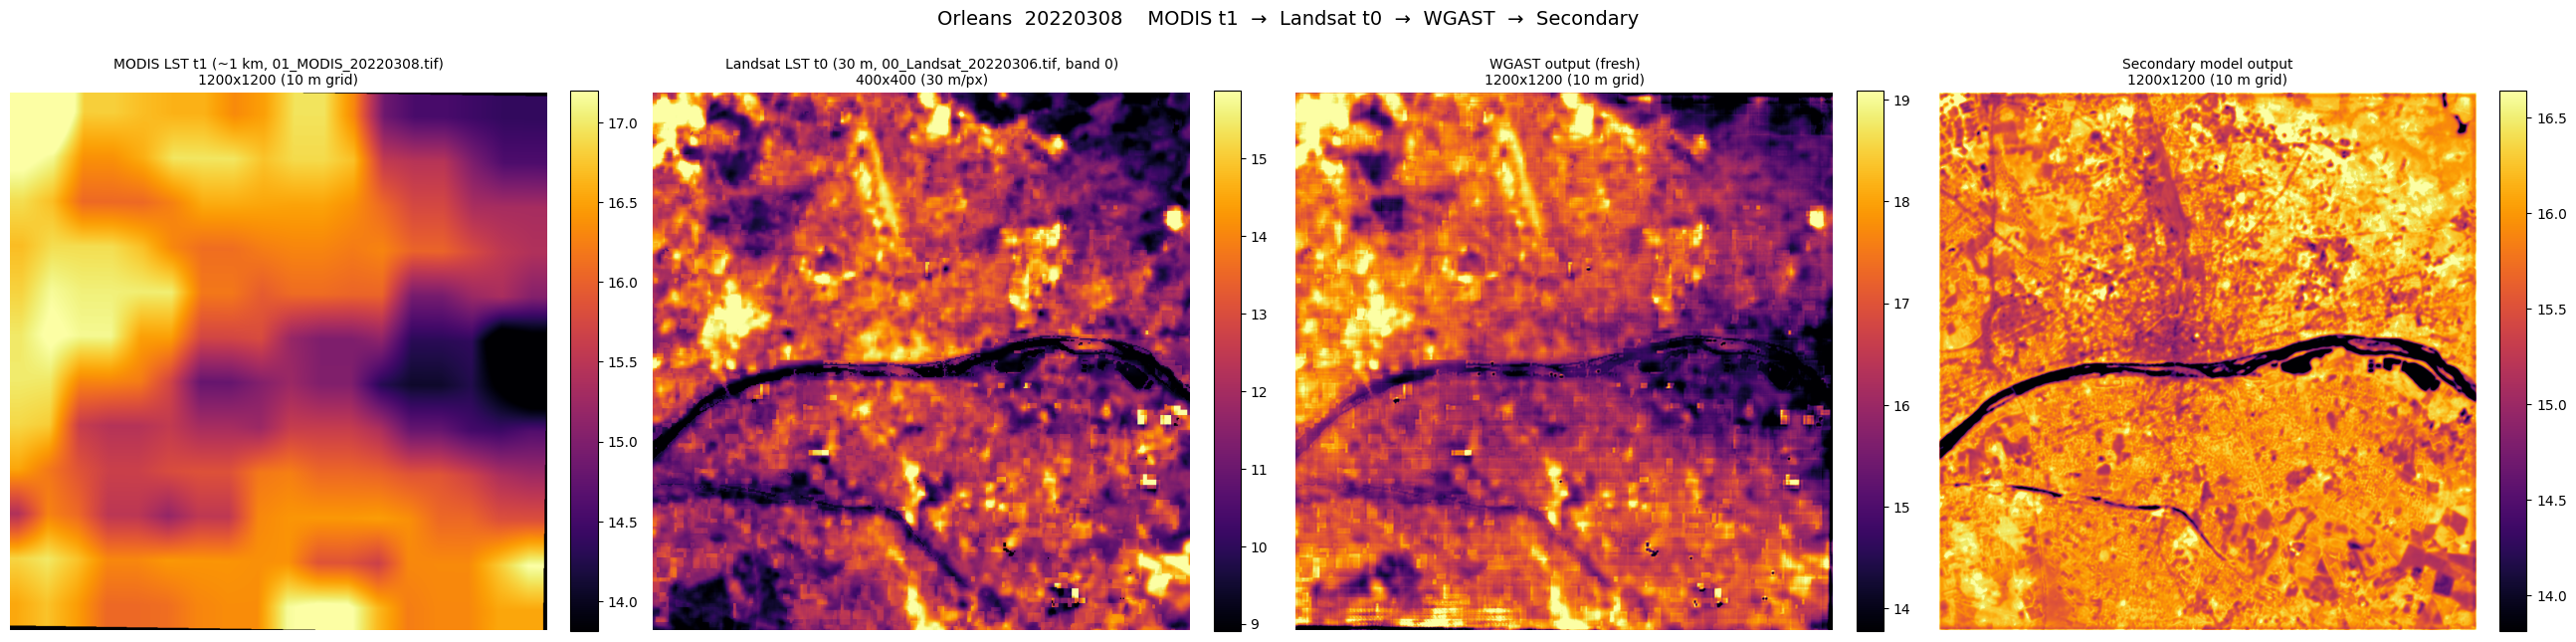

In [6]:
# === Side-by-side: MODIS t1 -> Landsat t0 -> WGAST -> Secondary ===
def pctl(a):
    a = a[np.isfinite(a)]
    return (np.percentile(a, 2), np.percentile(a, 98)) if a.size else (None, None)

panels = [(raw_modis,   modis_label),
          (raw_landsat, landsat_label),
          (wgast_out,   "WGAST output (fresh)"),
          (sec_out,     "Secondary model output")]

fig, axes = plt.subplots(1, 4, figsize=(26, 7))
for ax, (arr, title) in zip(axes, panels):
    vmin, vmax = pctl(arr)
    im = ax.imshow(arr, cmap="inferno", vmin=vmin, vmax=vmax)
    px = "30 m/px" if arr.shape[0] == 400 else "10 m grid"
    ax.set_title(f"{title}\n{arr.shape[0]}x{arr.shape[1]} ({px})", fontsize=10)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f"{CITY.title()}  {DEMO_DATE}    MODIS t1  →  Landsat t0  →  WGAST  →  Secondary", fontsize=14)
plt.tight_layout()
plt.show()
